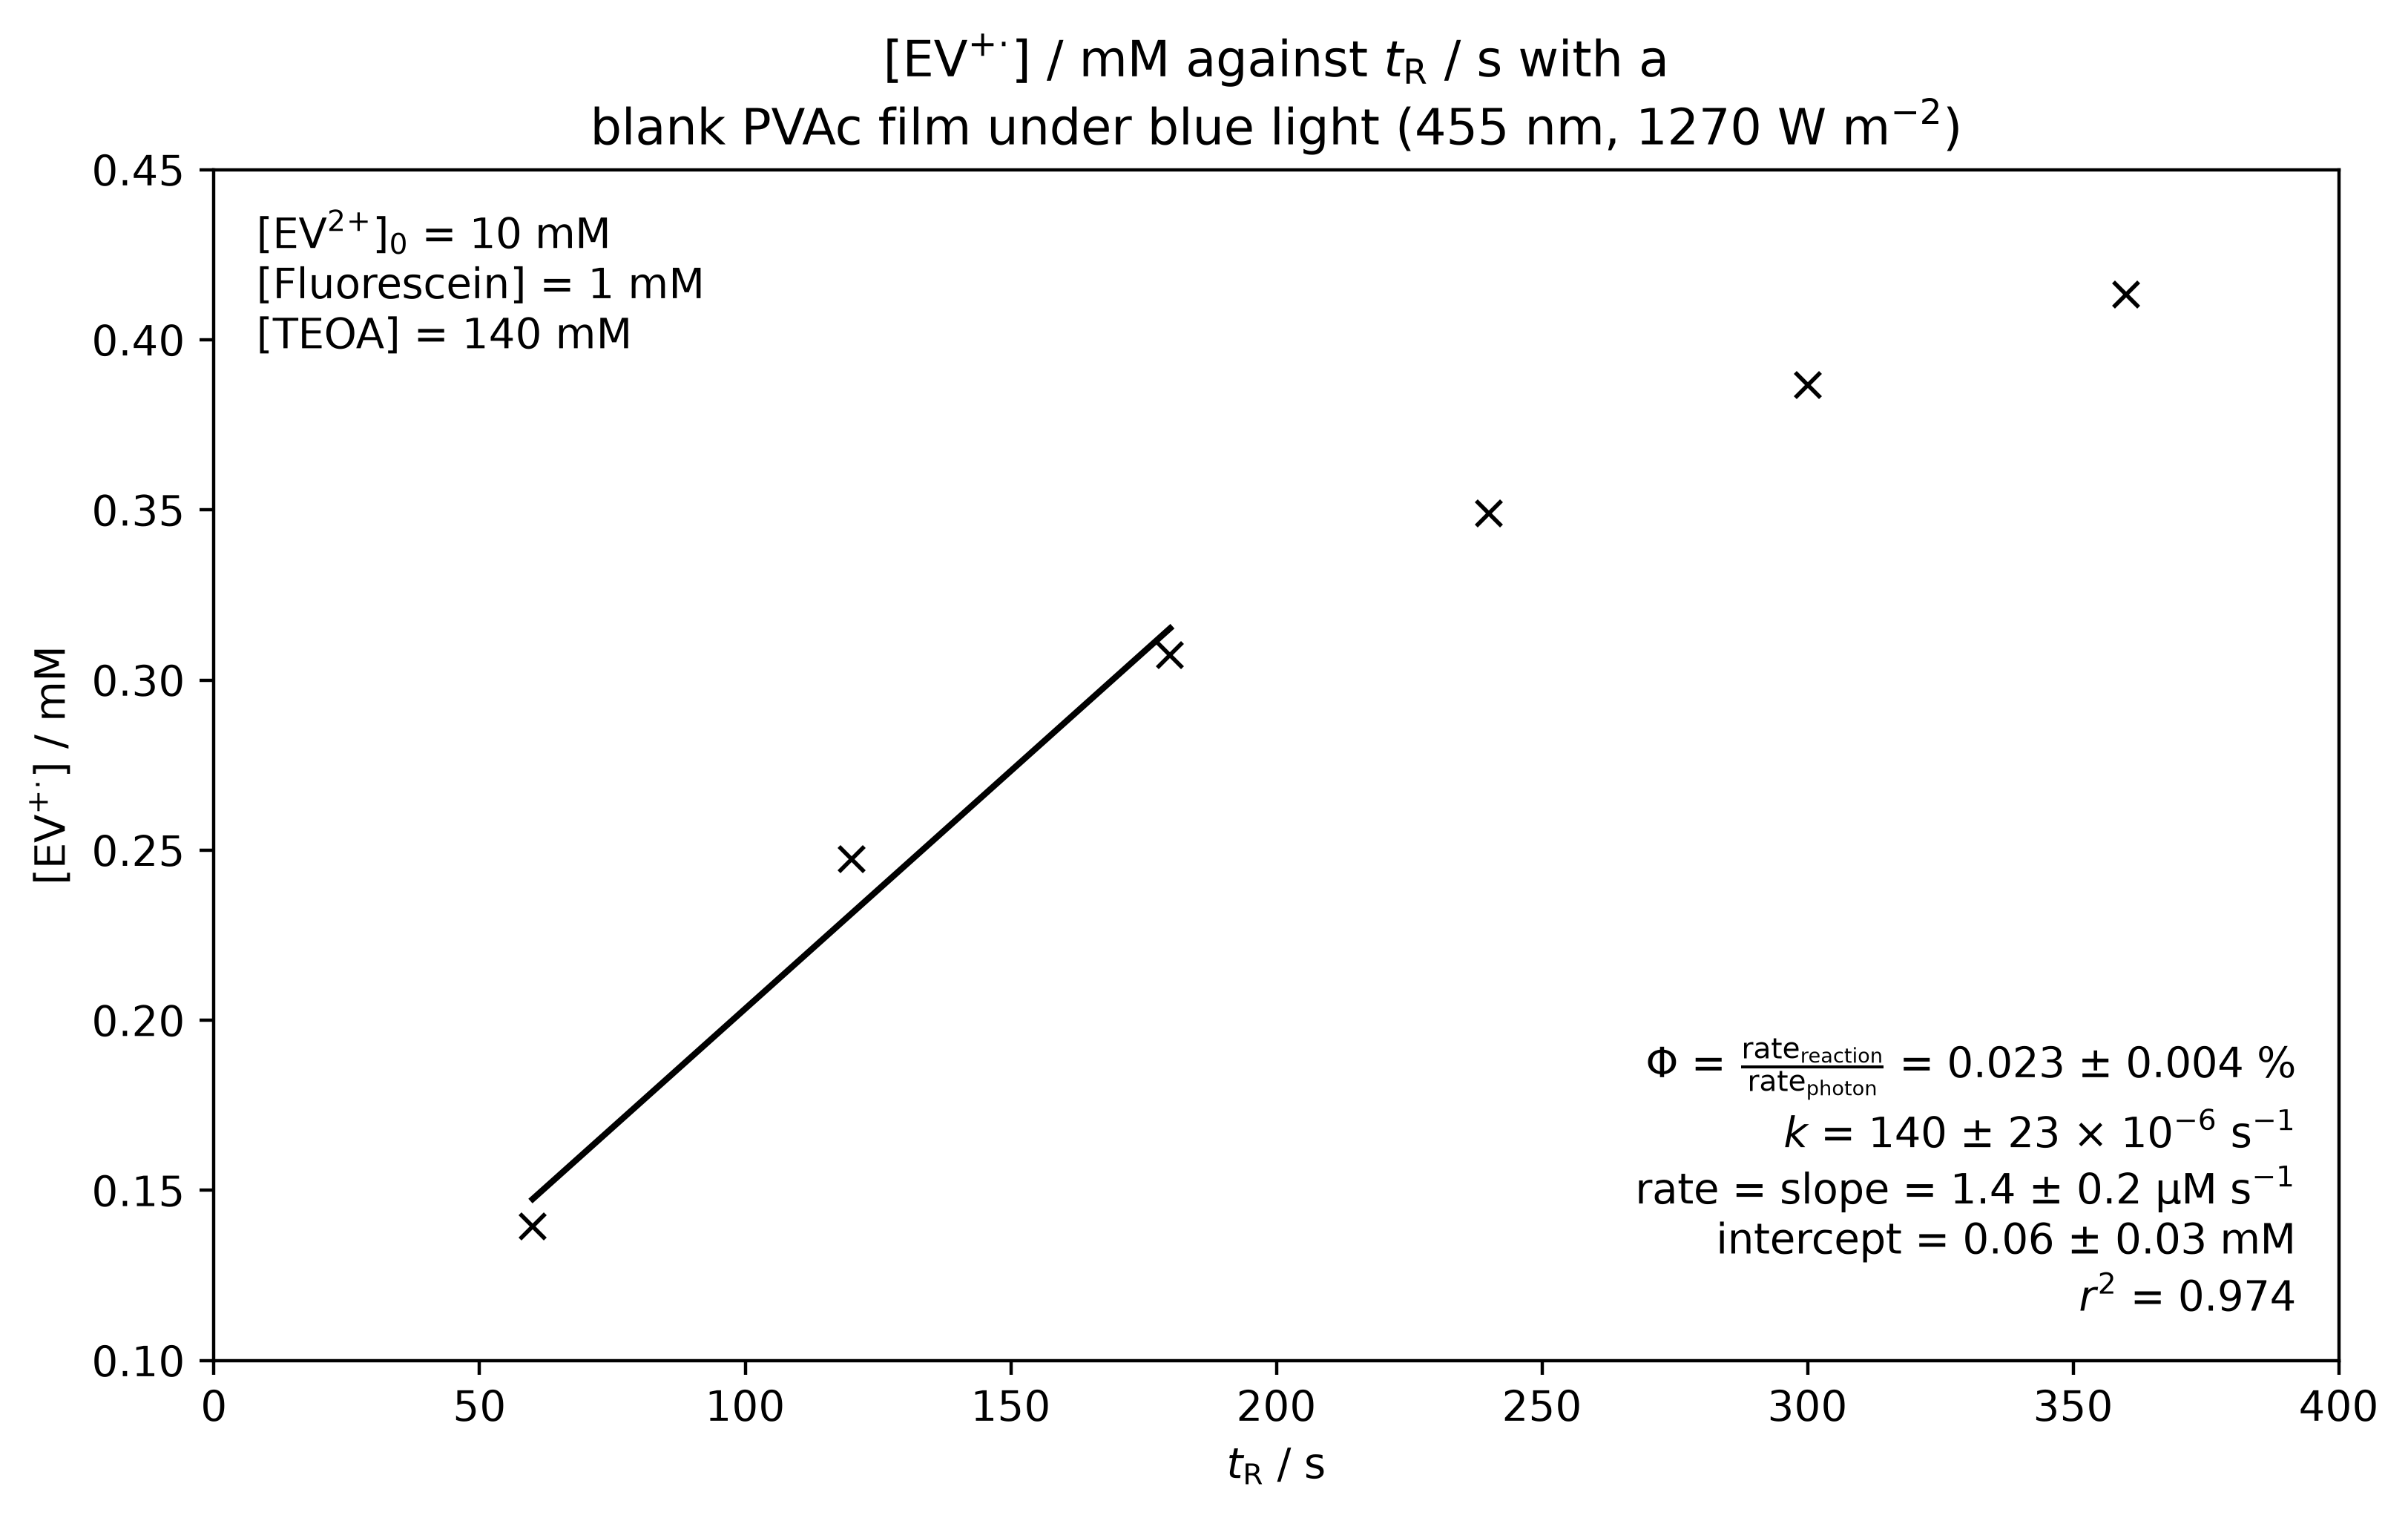

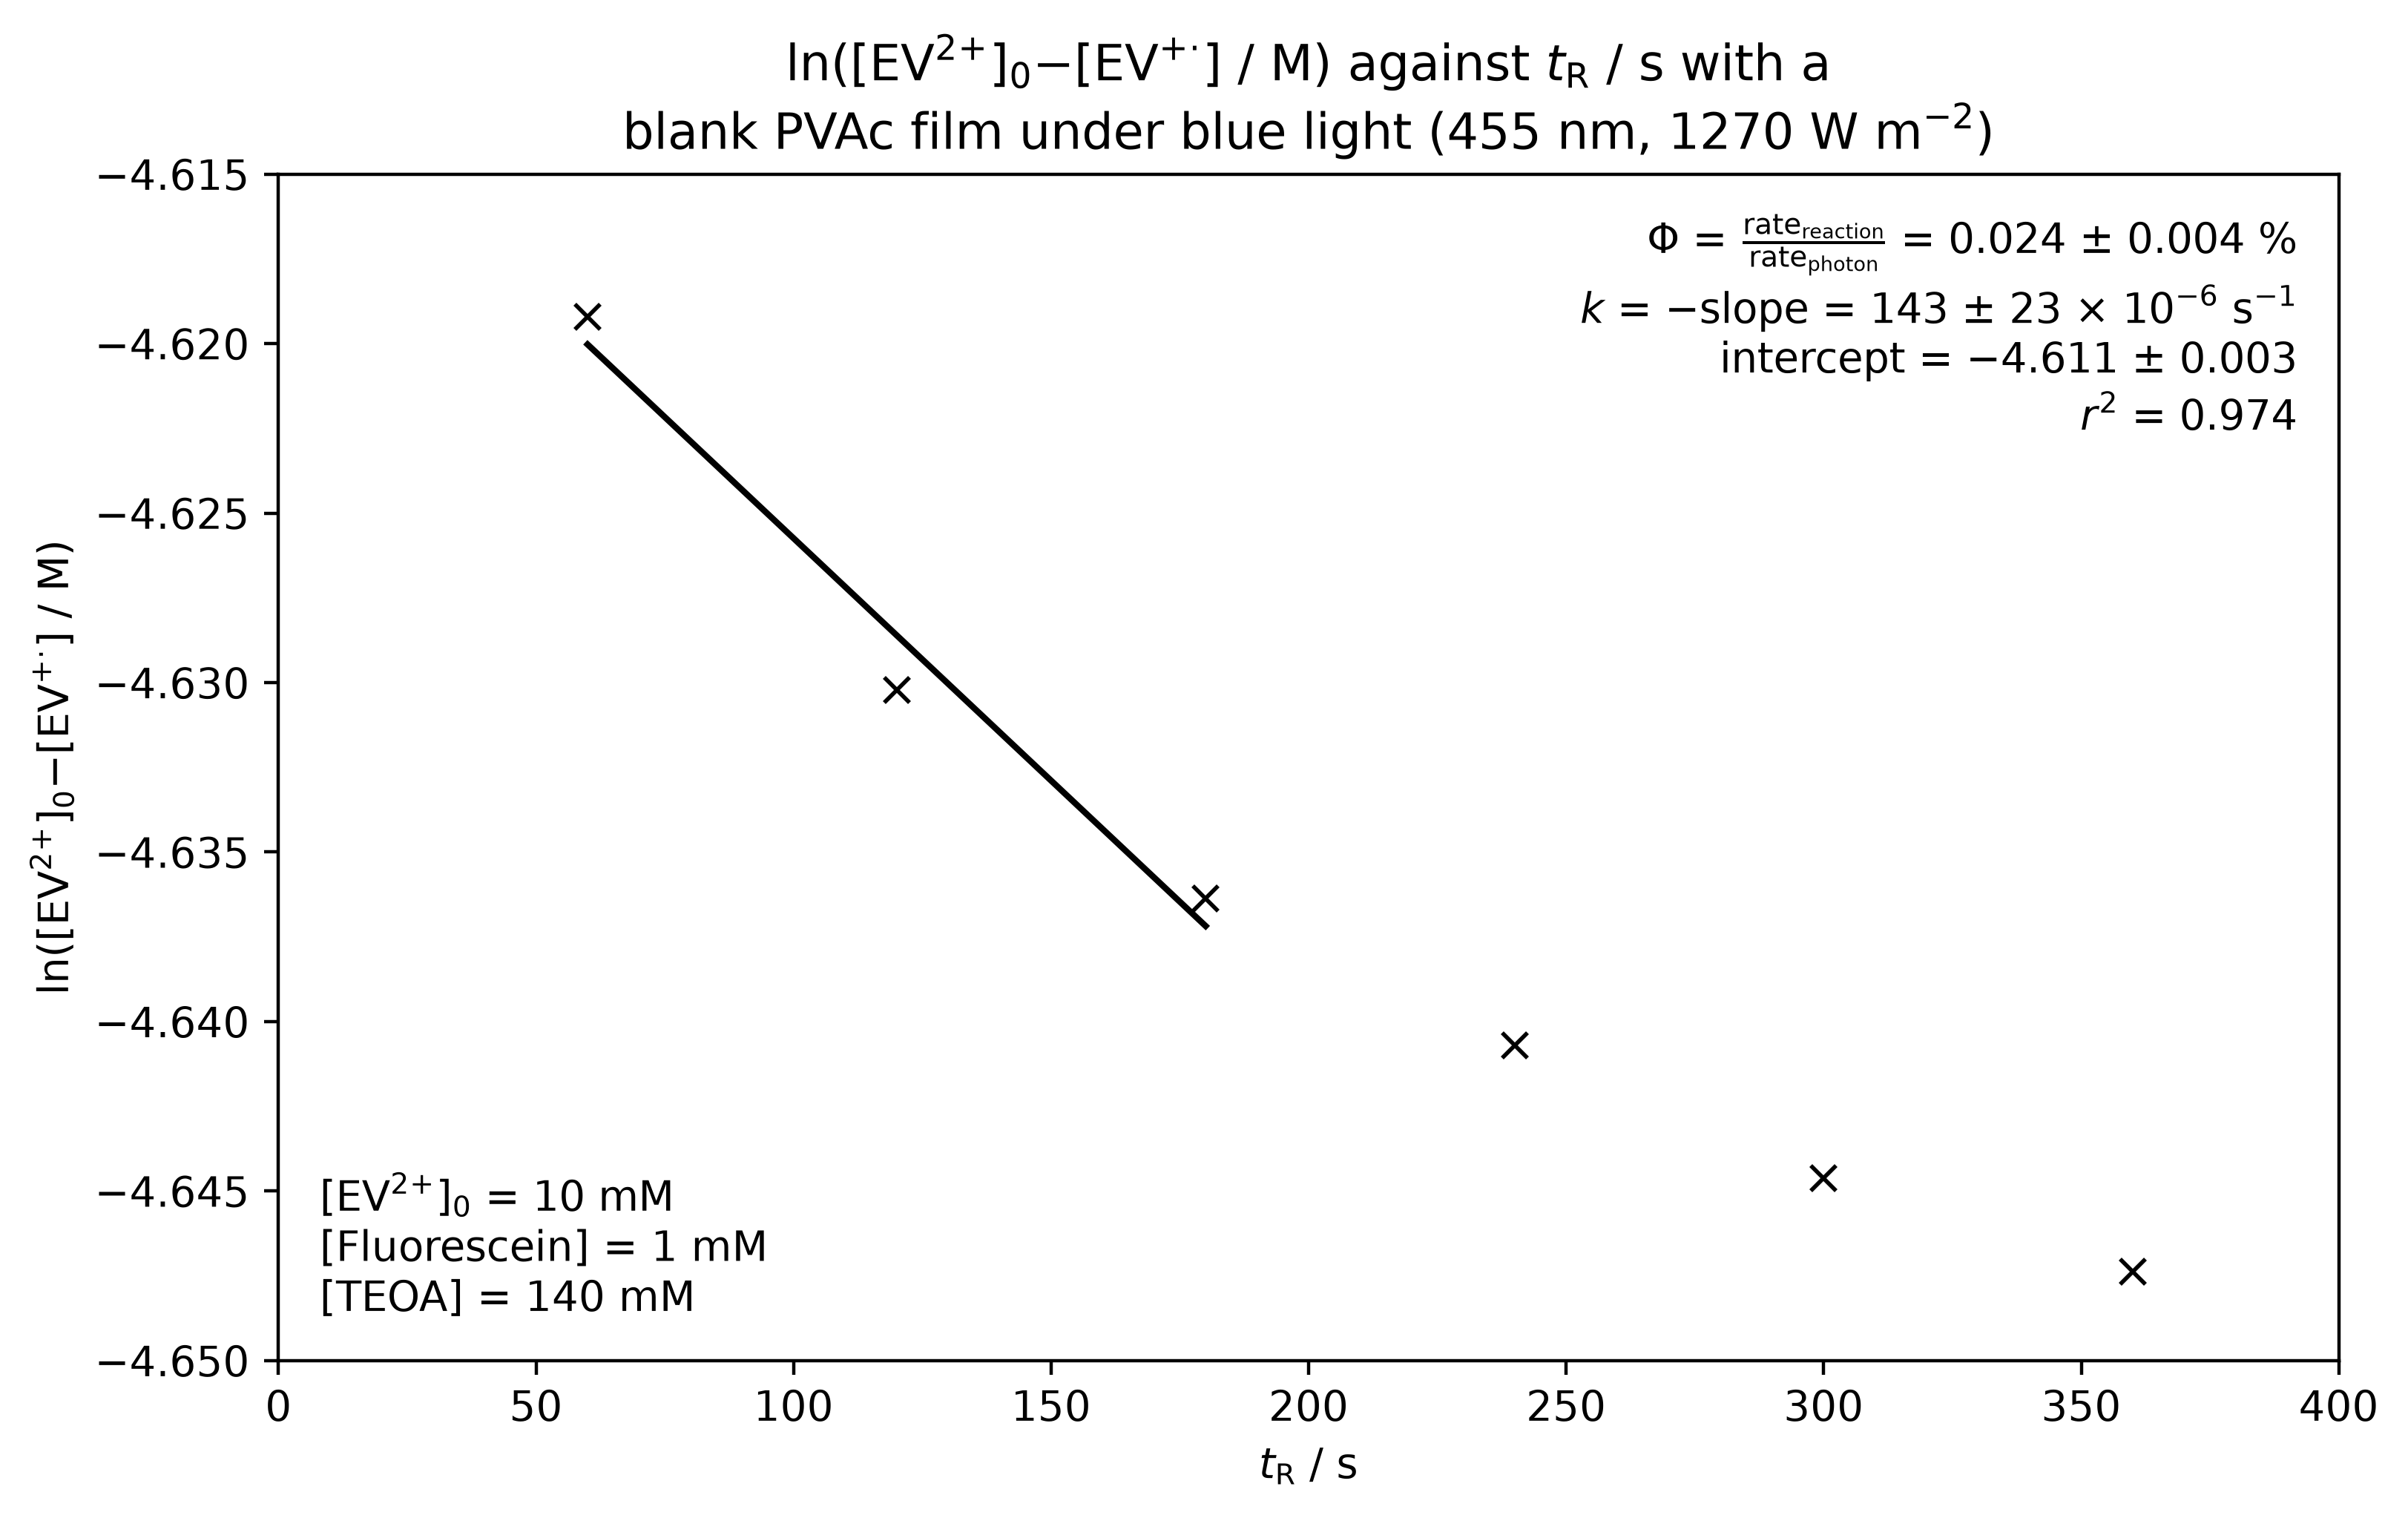

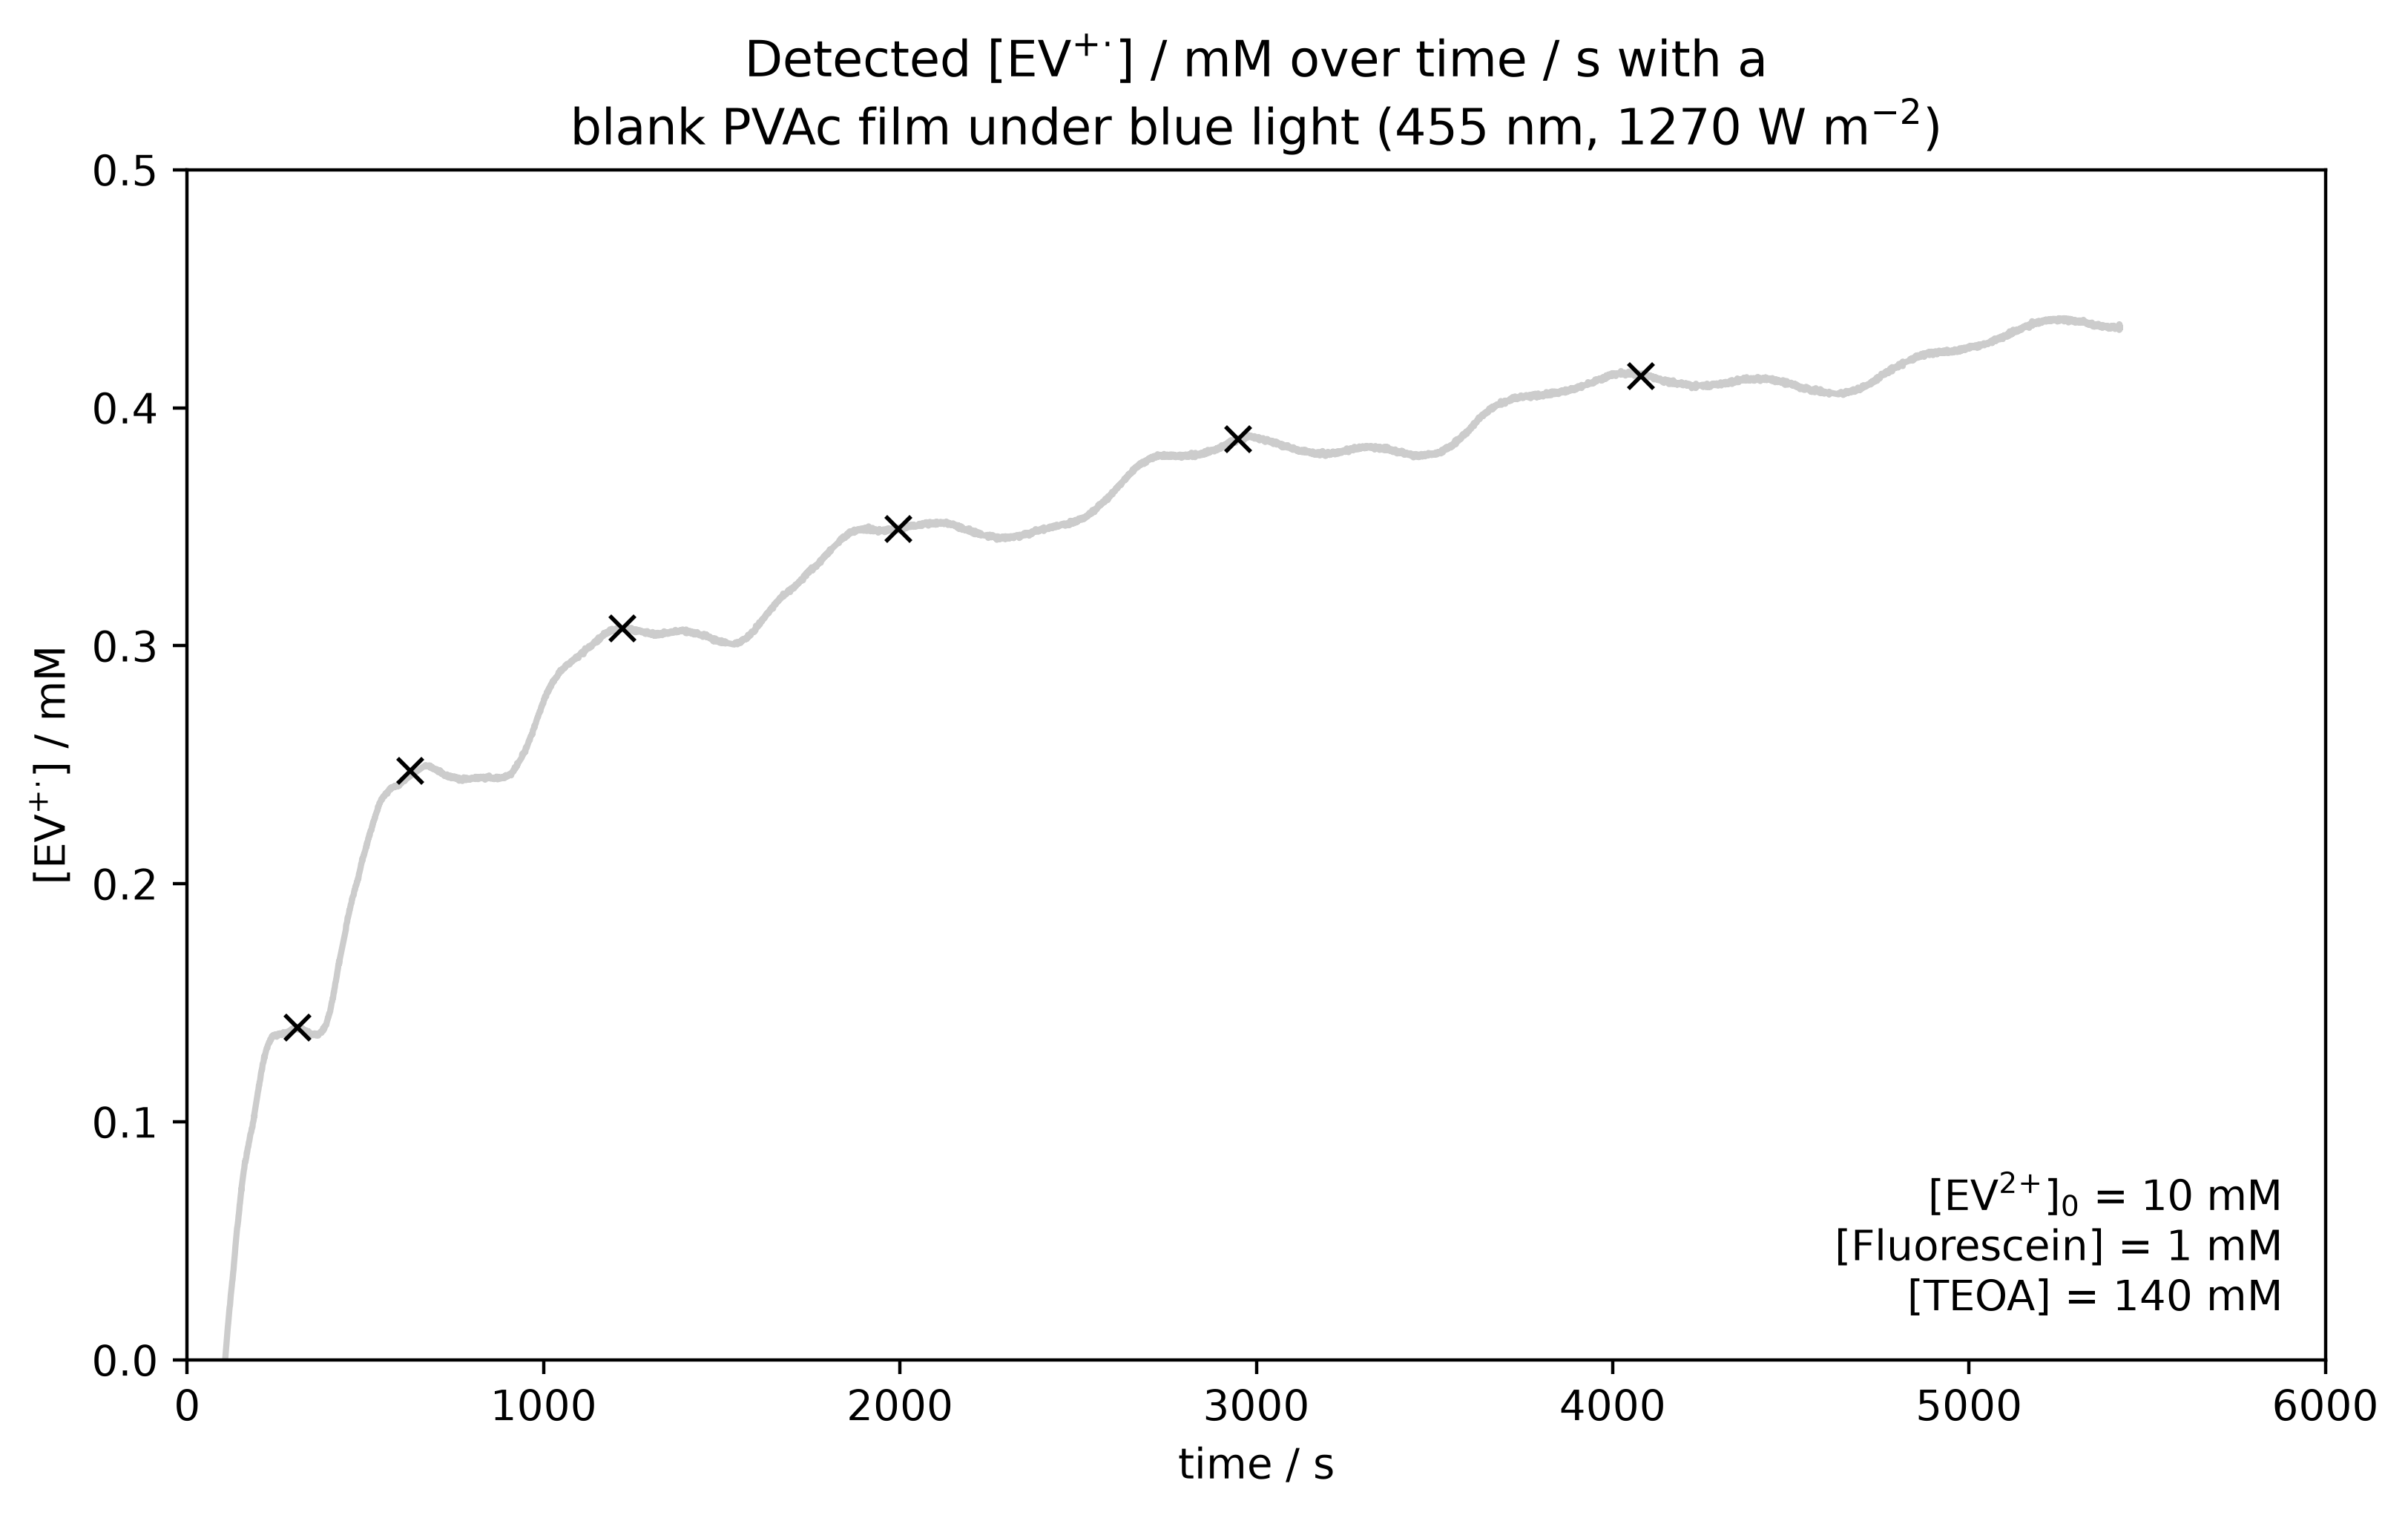

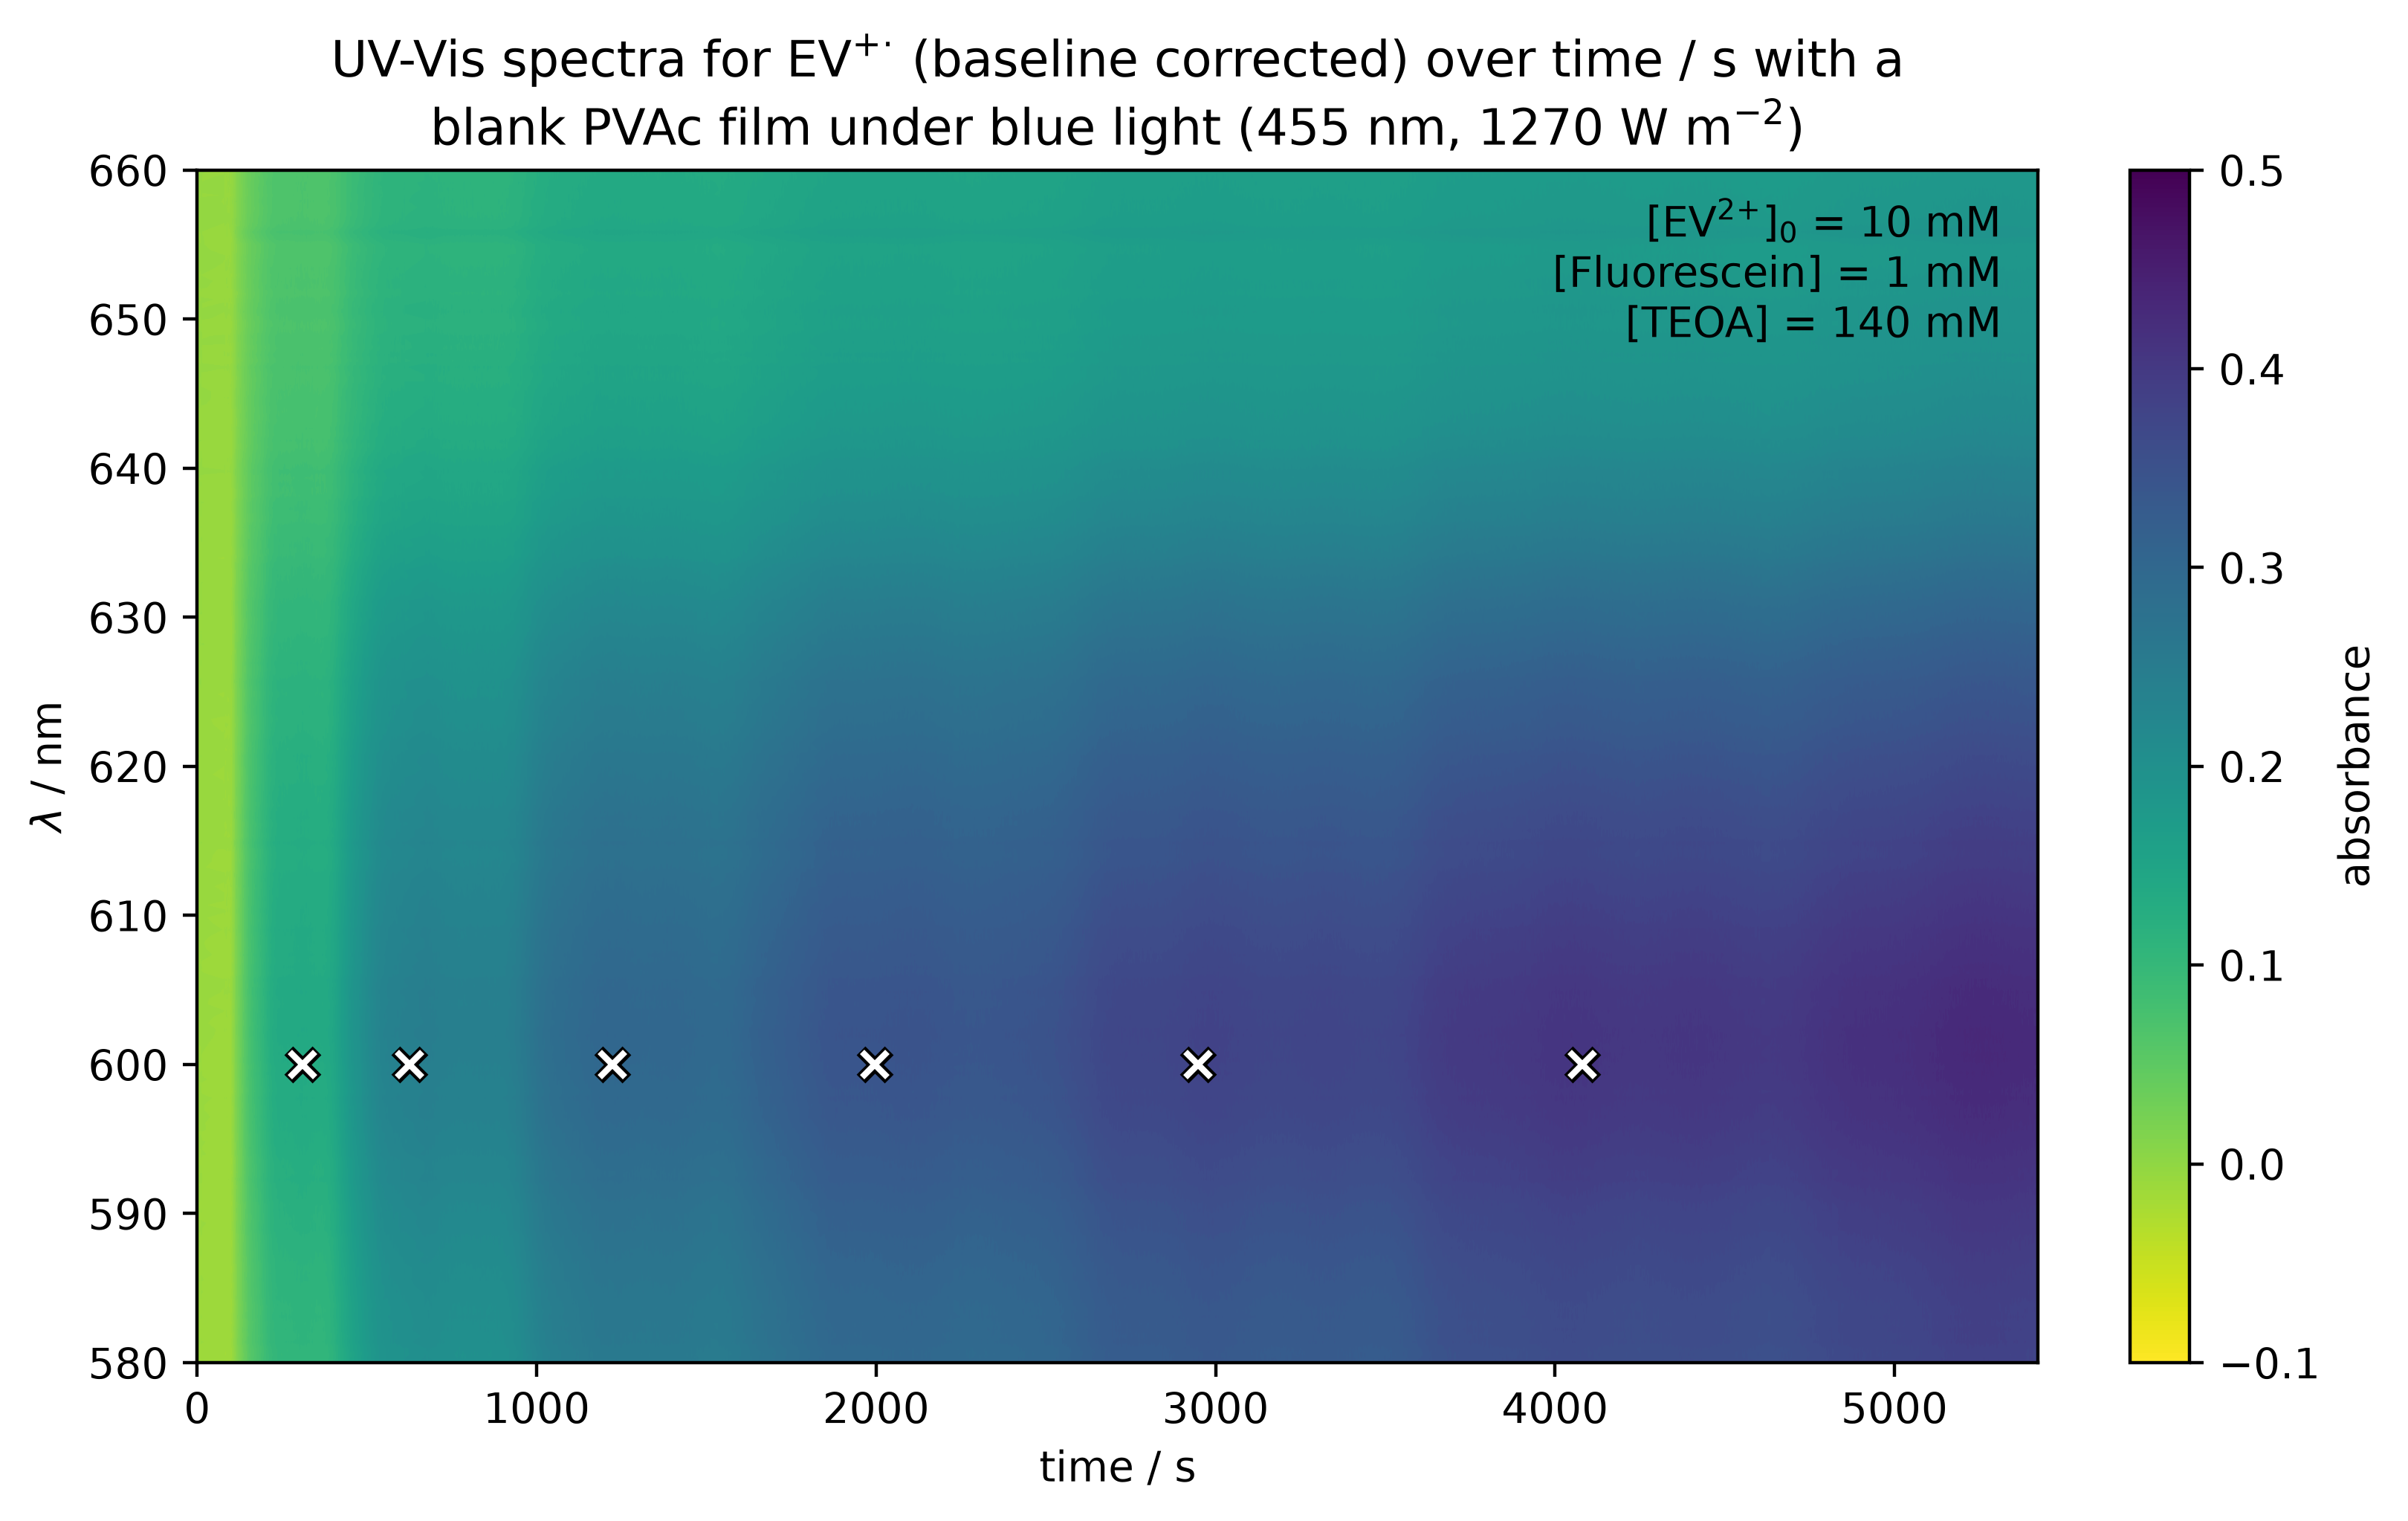

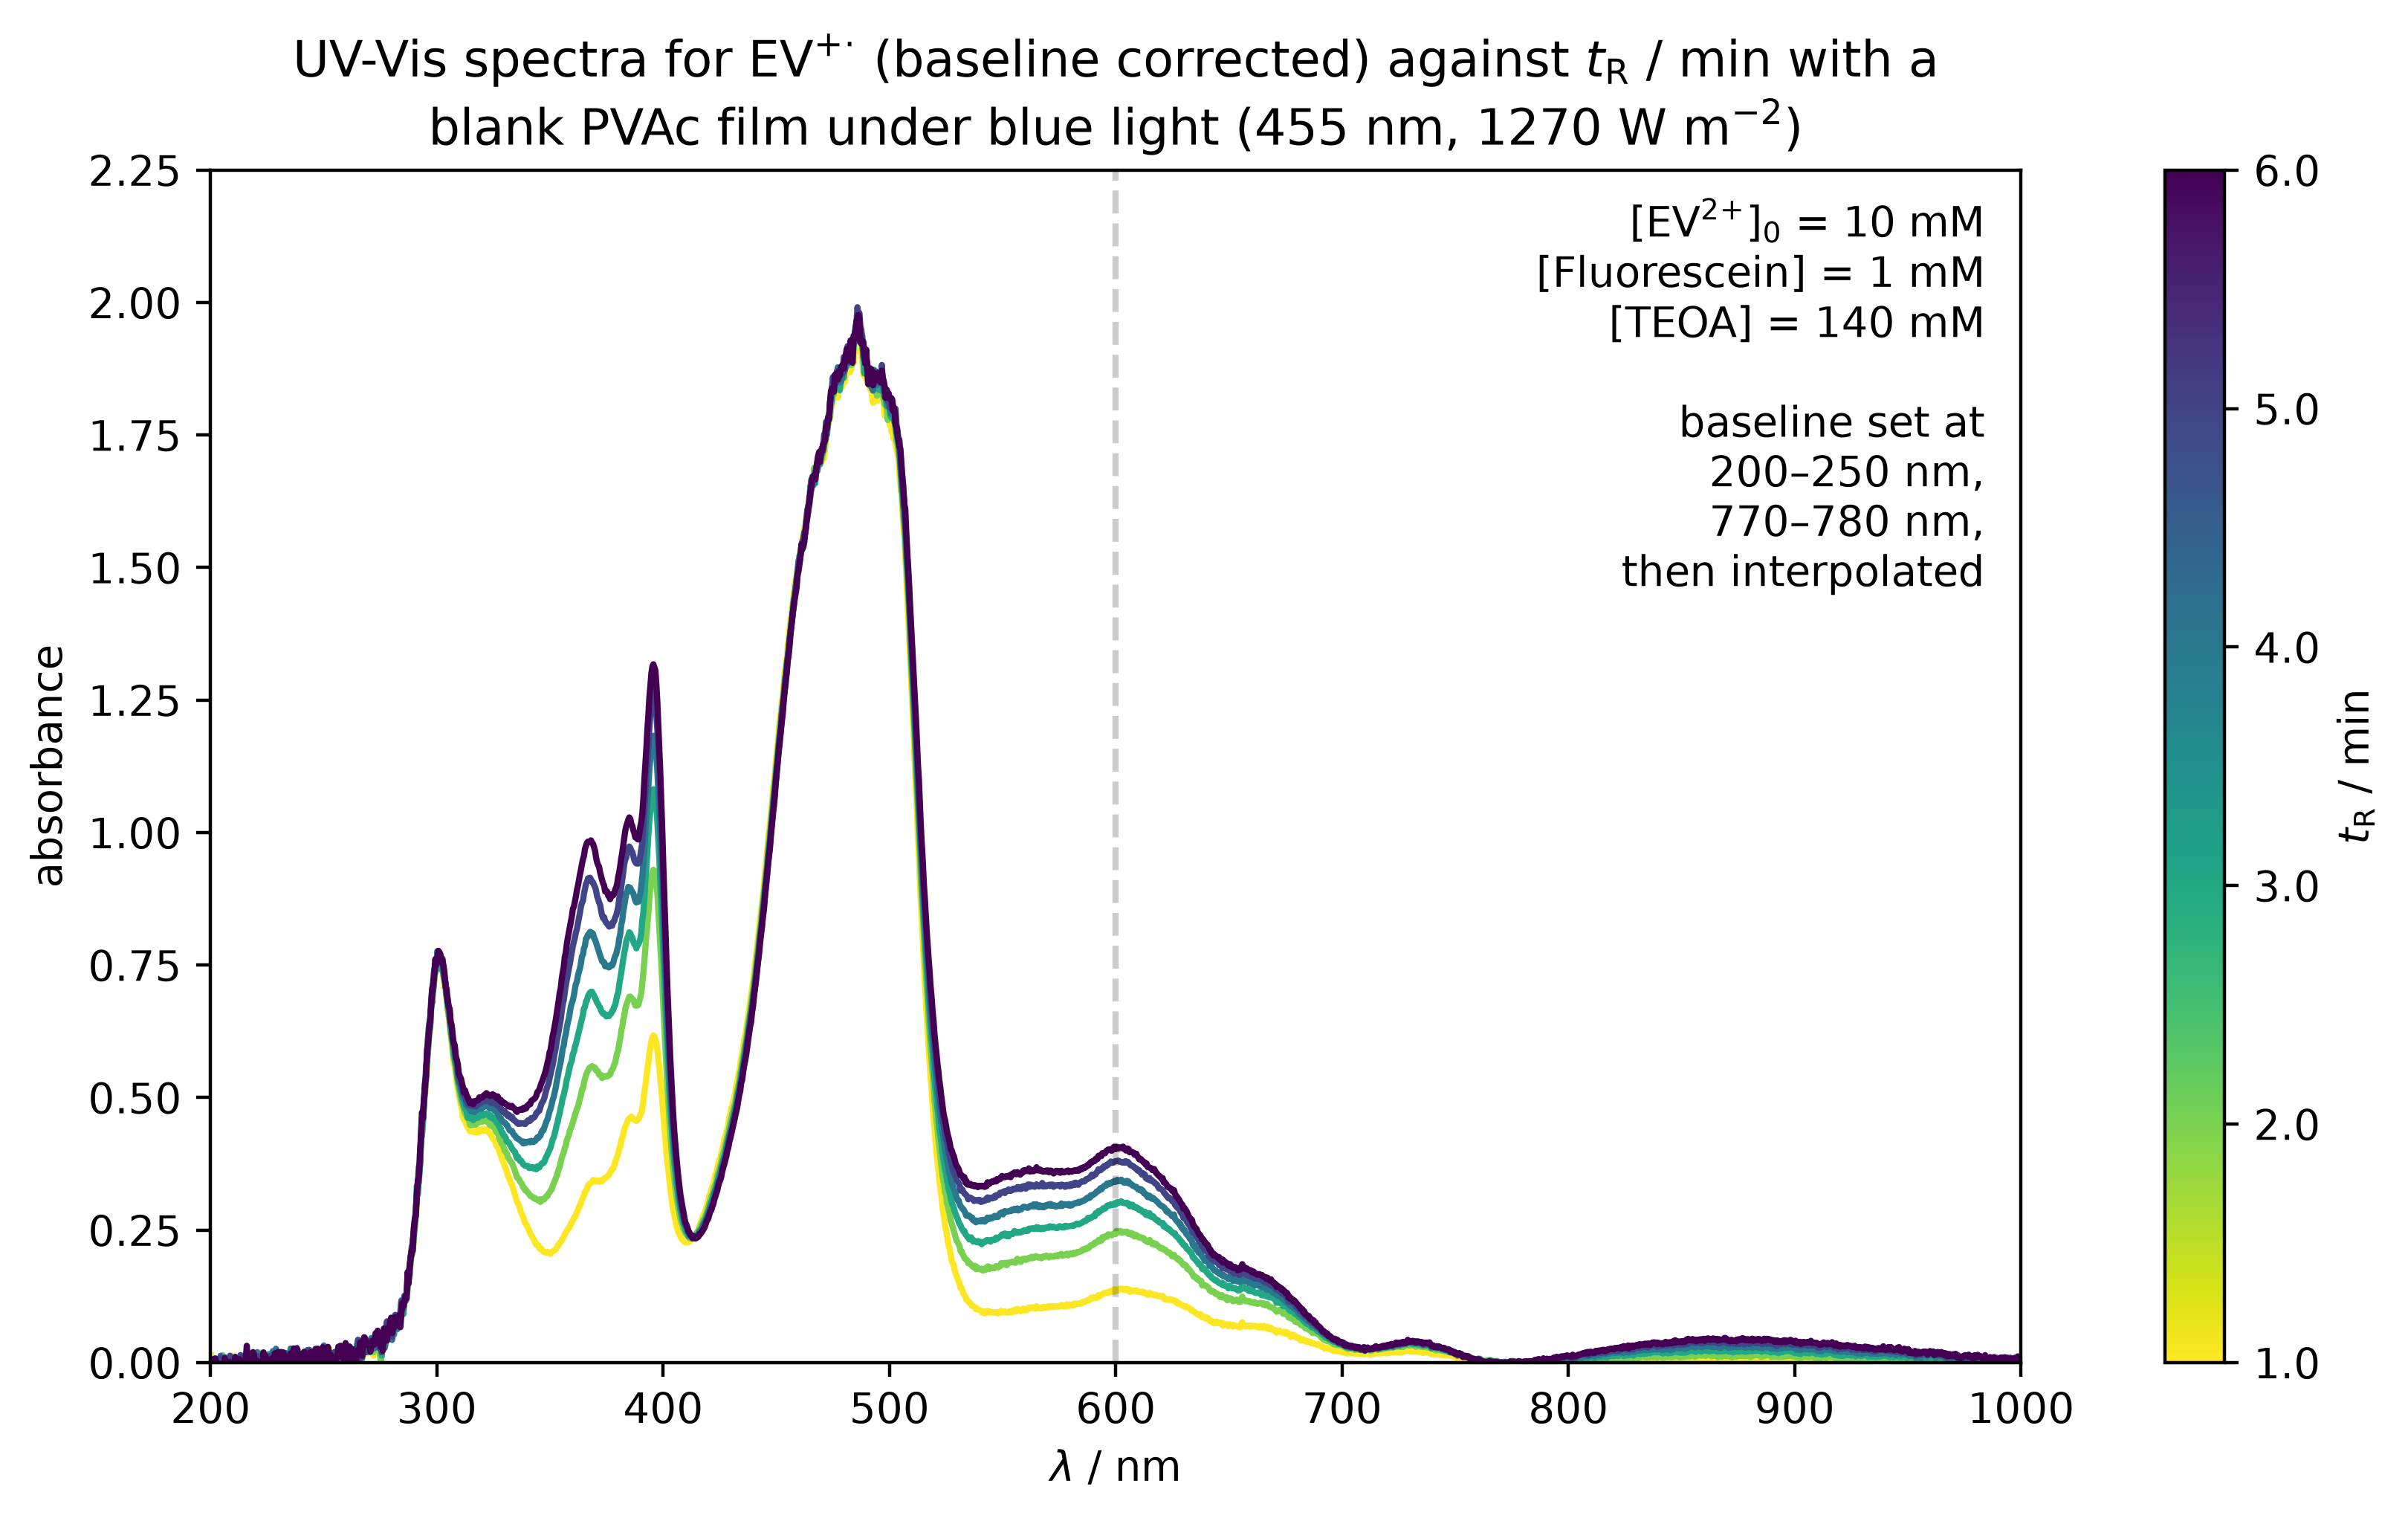

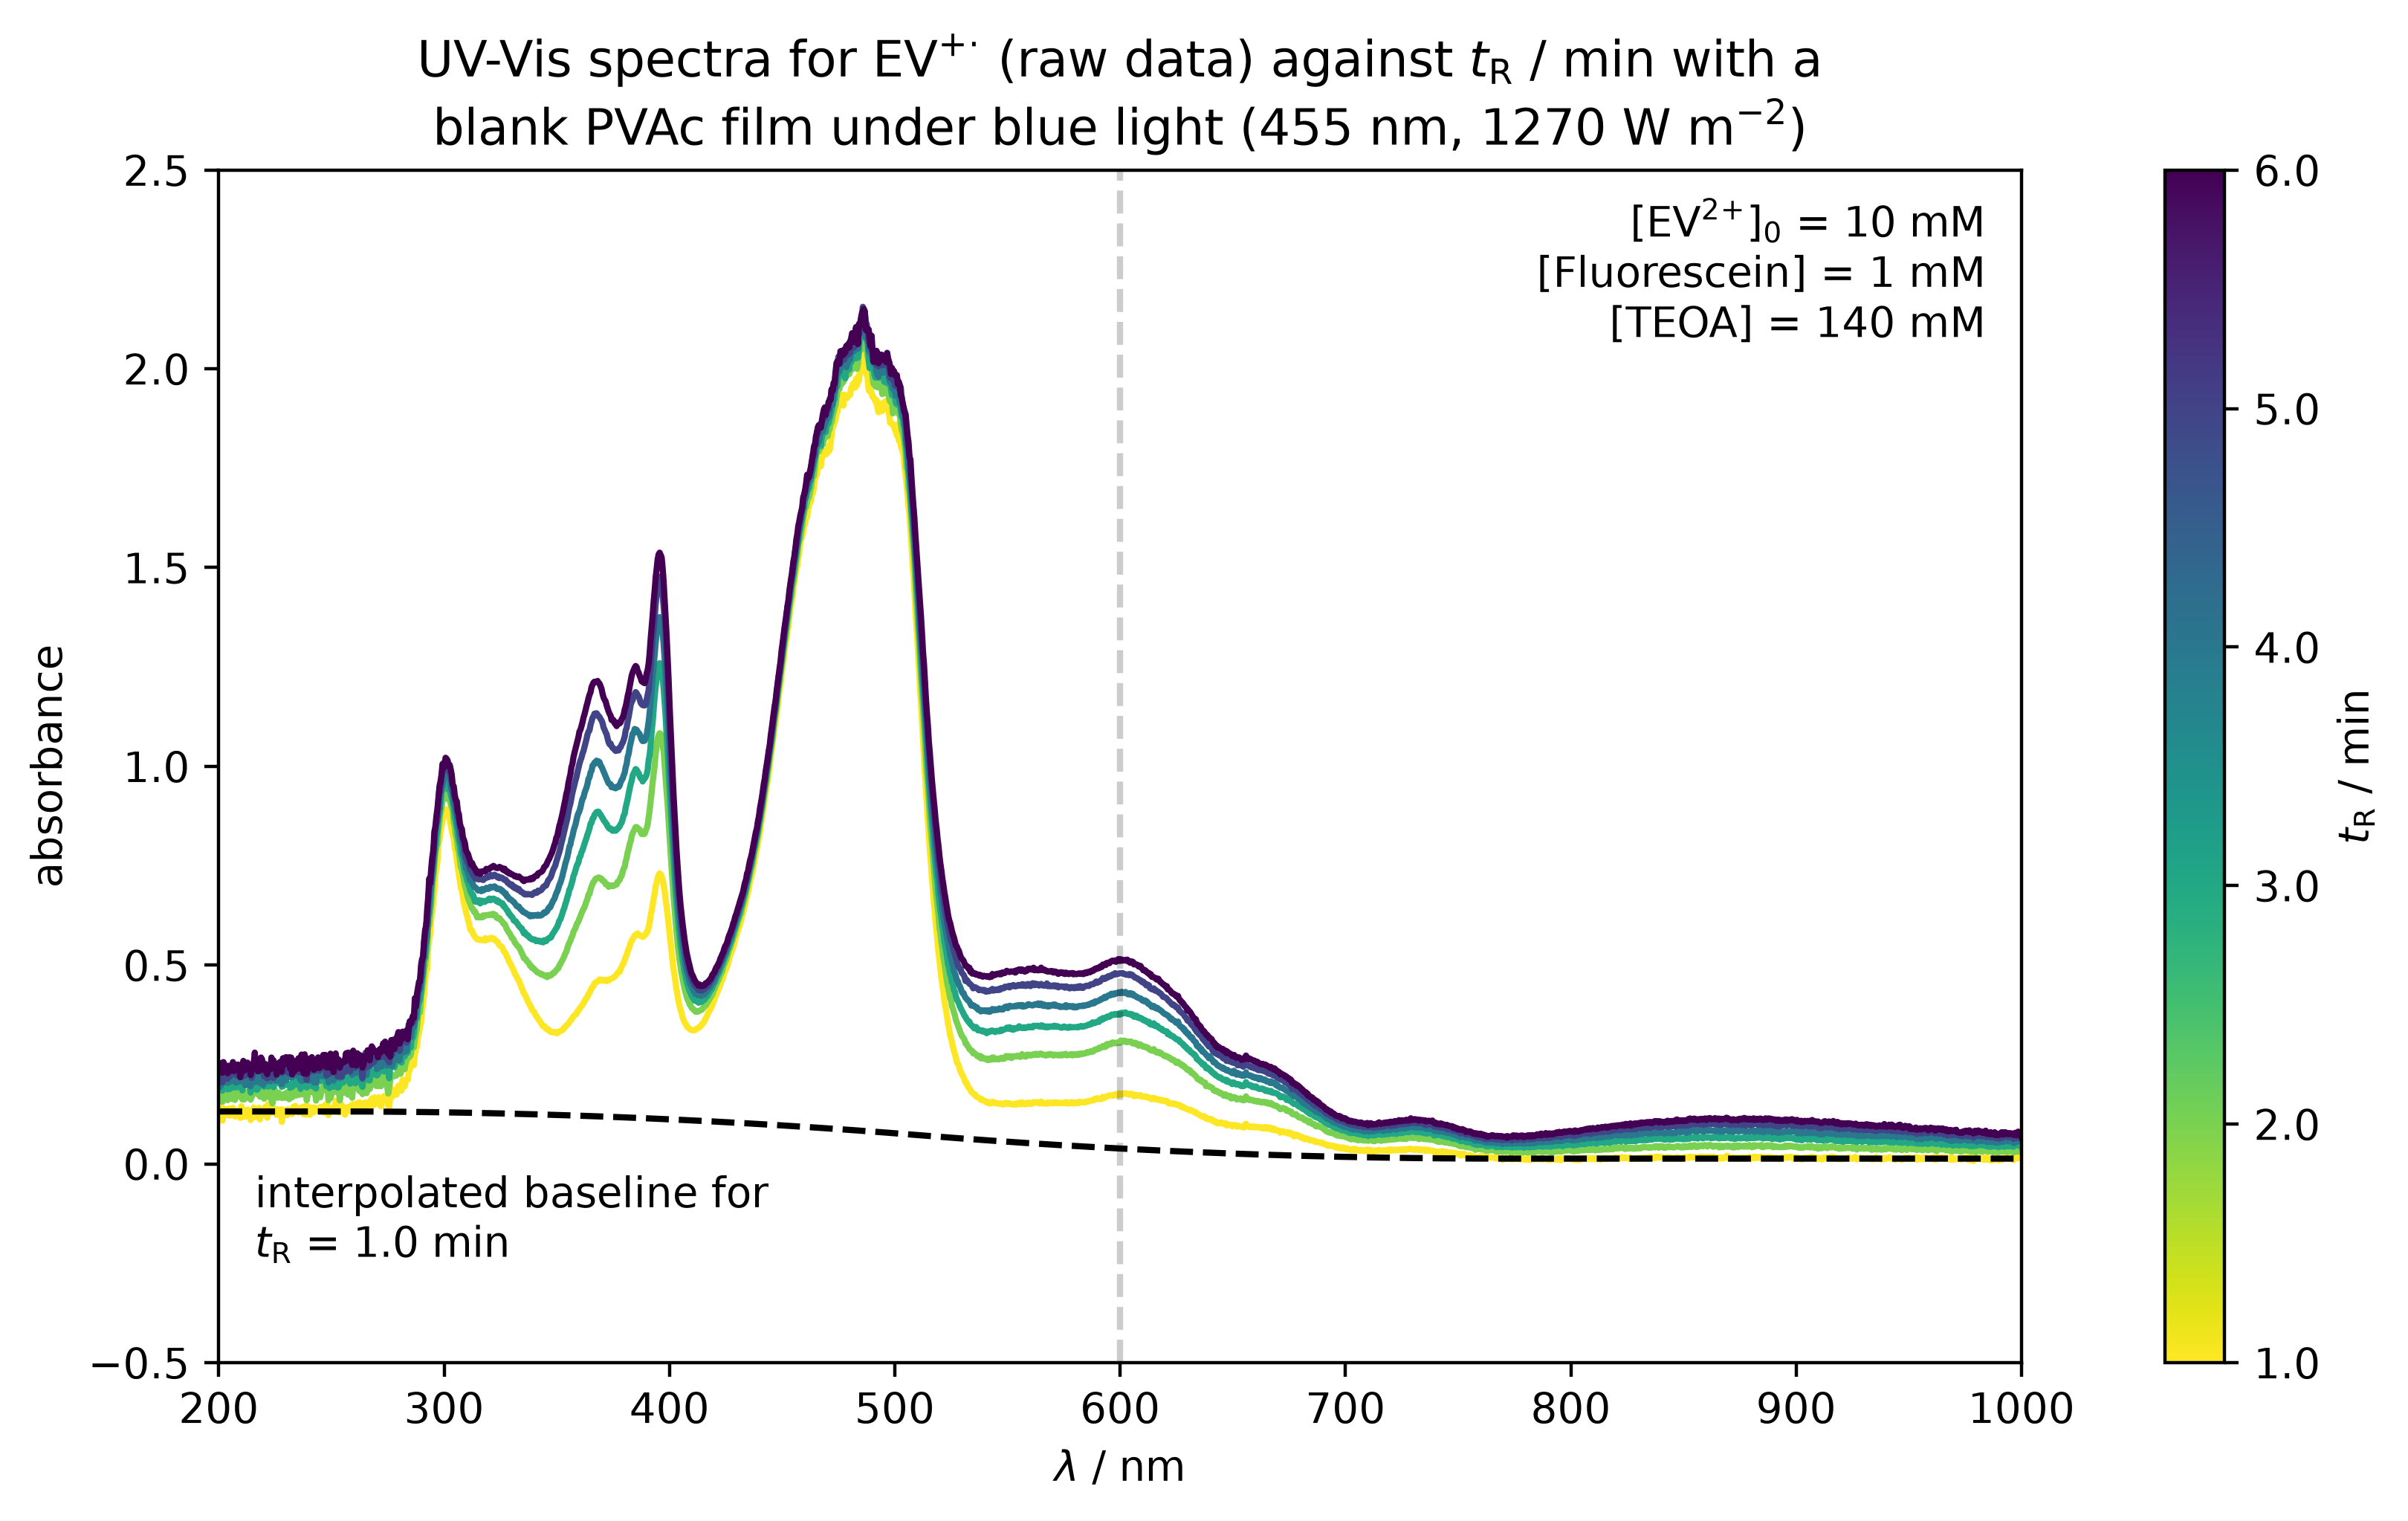

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Blue 455 nm irradiation at 90.0 mW.

Fluorescein TEOA trial 2 in flow.
- High power blue light.
- Took buffer solution as UV-Vis background.

V(Fluorescein, 5 mM, pH 7 buffer) = 600 ul (0.3 mM),
V(EV2+, 30 mM, pH 7 buffer) = 1000 ul (10 mM),
V(TEOA, 300 mM, pH 7 buffer) = 1400 ul (140 mM).
"""

data = '260813_Fluorescein_EV_TEOA_Blank_Blue_Flow' # data folder name

tRs = np.arange(60, 6*60+1, 60) # residence times/s for 1-6 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
points[0] += 100
start = "15-00-00-000" # recorded start time

c0 = 10e-3 # initial EV2+ concentration
details = '[Fluorescein] = 1 mM\n[TEOA] = 140 mM' # concentrations of other reagents

x = 'EVxantheneblue'
film = 'blank PVAc'
light = 'blue'
wavelength = 455e-9 # m
power = 90e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power, correction=True)
expt.concvstimeplot(iend=2)
expt.concvstimeplot(ln=True, iend=2)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()